In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("penguins.csv")
df = df.dropna()
X = df[['bill_length_mm', 'bill_depth_mm', 
        'flipper_length_mm', 'body_mass_g']]
y = df['species']
encoder = LabelEncoder()
y = encoder.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
tree = DecisionTreeClassifier(max_depth=4)
tree.fit(X_train, y_train)
predictions = tree.predict(X_test)
acc = accuracy_score(y_test, predictions)
print(round(acc,3))
print("enter the new data of new pengins")
a=[]
for i in range(0,4):
    d=float(input())
    a.append(d)
a=[a]
pre=tree.predict(a)
t=encoder.inverse_transform(pre)
print(pre)
print(t)

0.985
enter the new data of new pengins


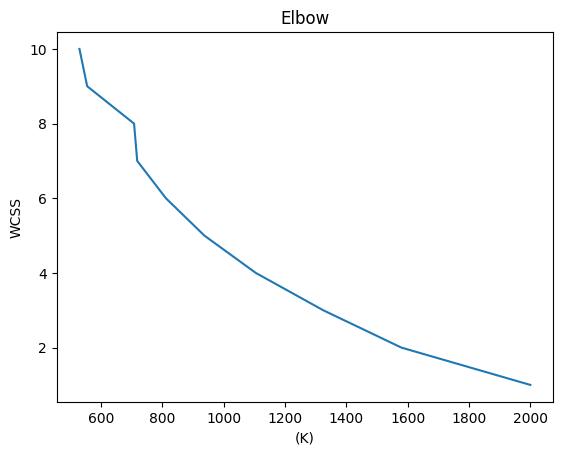

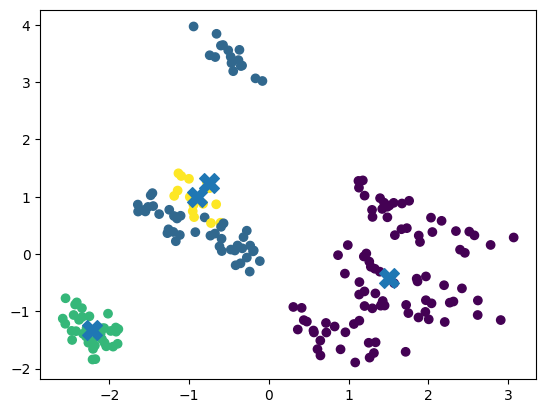

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("drug200.csv")
df = df.dropna()
df = pd.get_dummies(df, drop_first=True)
X = df
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
wcss = []
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    wcss.append(model.inertia_)
plt.plot( wcss,range(1, 11))
plt.xlabel("(K)")
plt.ylabel("WCSS")
plt.title("Elbow")
plt.show()
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_scaled)
from sklearn.decomposition import PCA
plt.figure()
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
clusters=kmeans.labels_
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.scatter(pca.transform(kmeans.cluster_centers_)[:, 0],
            pca.transform(kmeans.cluster_centers_)[:, 1],
            marker='X', s=200)

plt.show()
##df["Cluster"] = kmeans.labels_
##print(df.head())